# 05 — SDSS photometric-redshift prediction: model comparison and uncertainty

This notebook compares several ways to predict galaxy redshift from SDSS photometric magnitudes. It complements the previous notebook, where redshift was measured directly from an SDSS spectrum by identifying shifted emission lines.

Here the input is much poorer: only broadband `u`, `g`, `r`, `i`, `z` magnitudes are available. The target value is the SDSS spectroscopic redshift, `spec_z`, which is treated as the ground truth for supervised learning.

The aim is not to beat professional SDSS photo-z catalogues. The aim is to build a transparent class-project comparison between simple empirical models, tree ensembles, and a small neural-network-style model.


## Research question

**How accurately can different empirical models estimate spectroscopic redshift from SDSS photometric magnitudes, and which types of errors do they make?**

We compare:

1. **Median redshift baseline** — predicts the training-set median; every real model should beat this.
2. **Ridge regression** — linear baseline.
3. **k-nearest neighbours** — classical empirical method: similar colours imply similar redshifts.
4. **Decision tree** — simple nonlinear model, often prone to overfitting.
5. **Random forest** — ensemble of trees; usually more stable than one tree.
6. **Gradient boosting / histogram gradient boosting** — boosted tree ensembles for tabular data.
7. **MLP neural network** — a simple fully connected neural network using `scikit-learn`.
8. **Optional MLP ensemble** — several MLPs with different random initializations, used as a rough uncertainty proxy.

The supervised mapping is

$$
(u,g,r,i,z,\;u-g,g-r,r-i,i-z) \rightarrow z_{spec}.
$$


## Important distinction: spectroscopic vs photometric redshift

A **spectroscopic redshift** is measured from the wavelength shift of spectral lines. It is physically direct and usually precise, but spectra are expensive to obtain.

A **photometric redshift** is predicted from fluxes or magnitudes in a few broad filters. It is much less precise, but it can be obtained for vastly larger samples of objects.

Therefore, in this notebook the spectroscopic redshift is the target, while the model output is a photo-z prediction. If a raw CSV contains a column called `photometric_z`, this notebook checks whether it behaves like a z-band magnitude or a catalogue photo-z estimate before using it.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.photoz import (
    PHOTOZ_FEATURES,
    DEFAULT_SQL,
    add_catalog_photoz_metrics,
    binned_residual_summary,
    clean_photoz_sample,
    fit_and_evaluate_models,
    fit_mlp_ensemble_uncertainty,
    load_photoz_csv,
    photoz_metrics,
    photoz_sample_summary,
    plot_all_predicted_vs_true,
    plot_binned_residual_summary,
    plot_model_metric_comparison,
    plot_residual_comparisons,
    random_forest_tree_uncertainty,
    save_predictions_and_metrics,
    sdss_sql_url,
    stratified_photoz_sample,
    train_test_photoz,
    uncertainty_diagnostics,
)

RAW_CANDIDATES = [
    PROJECT_ROOT / 'data' / 'raw' / 'sdss_photoz_training_sample.csv',
    PROJECT_ROOT / 'data' / 'raw' / 'PhotoZ_SDSS.csv',
]
PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'sdss_photoz_clean.csv'
MODELING_SAMPLE = PROJECT_ROOT / 'data' / 'processed' / 'sdss_photoz_modeling_sample.csv'
FIGURES = PROJECT_ROOT / 'figures'
REPORT = PROJECT_ROOT / 'report'
MAX_MODEL_ROWS = 50000

FIGURES.mkdir(exist_ok=True)
REPORT.mkdir(exist_ok=True)
PROCESSED.parent.mkdir(parents=True, exist_ok=True)


## Official data source and reproducibility

The recommended dataset is downloaded from the official SDSS SkyServer SQL service. The query selects clean galaxies with valid spectroscopy and SDSS `ugriz` photometry.

Run this from the project root:

```bash
python download_sdss_photoz_sample.py
```

The notebook accepts either of these raw filenames:

```text
data/raw/sdss_photoz_training_sample.csv
data/raw/PhotoZ_SDSS.csv
```

For the included public-style CSV, `redshift` becomes the spectroscopic target `spec_z`, and `photometric_z` is interpreted as the SDSS z-band magnitude because its values are around ordinary magnitudes, not around redshift values.


In [2]:
print(sdss_sql_url(DEFAULT_SQL, data_release='dr17'))
print('\nSQL query used by the project downloader:')
print(DEFAULT_SQL)


https://skyserver.sdss.org/dr17/SkyServerWS/SearchTools/SqlSearch?cmd=SELECT+TOP+10000%0A++++p.objID%2C%0A++++p.ra%2C%0A++++p.dec%2C%0A++++p.modelMag_u+AS+u%2C%0A++++p.modelMag_g+AS+g%2C%0A++++p.modelMag_r+AS+r%2C%0A++++p.modelMag_i+AS+i%2C%0A++++p.modelMag_z+AS+zmag%2C%0A++++p.modelMagErr_u+AS+err_u%2C%0A++++p.modelMagErr_g+AS+err_g%2C%0A++++p.modelMagErr_r+AS+err_r%2C%0A++++p.modelMagErr_i+AS+err_i%2C%0A++++p.modelMagErr_z+AS+err_z%2C%0A++++s.z+AS+spec_z%2C%0A++++s.zWarning%0AFROM+PhotoObj+AS+p%0AJOIN+SpecObj+AS+s+ON+s.bestObjID+%3D+p.objID%0AWHERE%0A++++s.class+%3D+%27GALAXY%27%0A++++AND+s.z+BETWEEN+0.01+AND+0.6%0A++++AND+s.zWarning+%3D+0%0A++++AND+p.clean+%3D+1%0A++++AND+p.modelMag_u+BETWEEN+10+AND+28%0A++++AND+p.modelMag_g+BETWEEN+10+AND+28%0A++++AND+p.modelMag_r+BETWEEN+10+AND+28%0A++++AND+p.modelMag_i+BETWEEN+10+AND+28%0A++++AND+p.modelMag_z+BETWEEN+10+AND+28%0A++++AND+p.modelMagErr_u+BETWEEN+0+AND+1%0A++++AND+p.modelMagErr_g+BETWEEN+0+AND+1%0A++++AND+p.modelMagErr_r+BETWEEN+0+A

## Load raw data

Real astronomical catalogues are rarely ready for modelling without checks. We first load the CSV and normalize column names so that both the project-downloaded SDSS query and the compatible `PhotoZ_SDSS.csv` table can be used.


In [3]:
RAW = next((path for path in RAW_CANDIDATES if path.exists()), None)
if RAW is None:
    raise FileNotFoundError(
        'Missing SDSS photo-z CSV. Run `python download_sdss_photoz_sample.py`, '
        'or save your CSV as data/raw/sdss_photoz_training_sample.csv or data/raw/PhotoZ_SDSS.csv.'
    )

raw = load_photoz_csv(RAW)
print('Using raw file:', RAW.relative_to(PROJECT_ROOT))
print('Raw shape:', raw.shape)
print('Columns:', list(raw.columns))
if 'photometric_z' in raw.columns and 'zmag' in raw.columns:
    print('photometric_z median:', pd.to_numeric(raw['photometric_z'], errors='coerce').median())
    print('zmag median after alias normalization:', raw['zmag'].median())
raw.head()


Using raw file: data/raw/PhotoZ_SDSS.csv
Raw shape: (1000000, 14)
Columns: ['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'photometric_z', 'specObjID', 'redshift', 'redshift_error', 'class', 'spec_z', 'zmag']
photometric_z median: 16.71577
zmag median after alias normalization: 16.71577


,objid,ra,dec,u,g,r,i,photometric_z,specObjID,redshift,redshift_error,class,spec_z,zmag
0,1237657877538406672,116.120394,22.545785,24.56870,21.61409,22.12696,21.32540,21.38752,5032798515845419008,1.208629e-07,0.000119,GALAXY,1.208629e-07,21.38752
1,1237663783144194772,46.998370,-0.830104,24.07251,20.66000,20.13897,19.84265,19.68270,913172214314985472,1.267802e-07,0.000053,GALAXY,1.267802e-07,19.68270
2,1237680529198940388,332.536372,25.377382,24.63465,22.93031,21.14673,19.94050,20.18146,6708185691363495936,2.121375e-07,0.000059,GALAXY,2.121375e-07,20.18146
3,1237663547978744571,130.401203,58.256154,25.49103,23.31337,21.79658,20.59253,19.47360,9224594267057704960,4.250481e-07,0.000027,GALAXY,4.250481e-07,19.47360
4,1237662666425827520,246.576703,24.555668,24.63449,18.96386,17.51325,16.66019,16.41736,1772187952164661248,4.440446e-07,0.000009,GALAXY,4.440446e-07,16.41736


## Preprocessing and feature engineering

The cleaning step is part of the scientific method, not just housekeeping. It performs:

1. numeric conversion of magnitudes, redshifts, errors and flags;
2. removal of missing or infinite values;
3. SDSS quality filtering using `zWarning = 0` when available;
4. cuts to keep galaxy rows, plausible magnitudes, `0.01 <= z_spec <= 0.6`, and small spectroscopic-redshift errors;
5. removal of extreme colour outliers that usually indicate bad photometry;
6. construction of colour indices:

$$
u-g, \quad g-r, \quad r-i, \quad i-z.
$$

A large raw CSV can make notebook execution slow and produce huge report files, so the modelling step uses a reproducible redshift-stratified sample. The full cleaned table is still saved separately.


In [4]:
clean = clean_photoz_sample(raw, z_min=0.01, z_max=0.6, max_redshift_error=0.01)
modeling = stratified_photoz_sample(clean, max_rows=MAX_MODEL_ROWS, random_state=42)

clean.to_csv(PROCESSED, index=False)
modeling.to_csv(MODELING_SAMPLE, index=False)

sample_summary = pd.DataFrame([
    photoz_sample_summary(raw.dropna(subset=['spec_z']), 'raw_loaded'),
    photoz_sample_summary(clean, 'clean_after_quality_cuts'),
    photoz_sample_summary(modeling, f'modeling_stratified_max_{MAX_MODEL_ROWS}'),
])
sample_summary.to_csv(REPORT / 'photoz_sample_summary.csv', index=False)

print('Raw rows:', len(raw))
print('Clean rows:', len(clean))
print('Modeling rows:', len(modeling))
sample_summary


Raw rows: 1000000
Clean rows: 983821
Modeling rows: 50000


,sample,n,z_min,z_median,z_max
0,raw_loaded,1000000,1.208629e-07,0.120447,0.309207
1,clean_after_quality_cuts,983821,1.000031e-02,0.120971,0.309207
2,modeling_stratified_max_50000,50000,1.006560e-02,0.120991,0.309200


In [5]:
modeling[PHOTOZ_FEATURES + ['spec_z']].describe().T


,count,mean,std,min,25%,50%,75%,max
u,50000.0,20.213487,1.542145,14.653880,19.227515,20.012355,20.999313,27.41583
g,50000.0,18.468972,1.328014,12.671850,17.713932,18.328780,19.055327,25.21963
r,50000.0,17.524685,1.256345,11.804240,16.889955,17.448905,17.869465,24.15388
i,50000.0,17.088079,1.260326,11.337460,16.465072,17.017790,17.428247,24.36180
zmag,50000.0,16.792978,1.305979,11.024810,16.151000,16.708065,17.156210,23.58279
u_g,50000.0,1.744514,0.622055,-0.996650,1.347553,1.775420,2.011040,5.99663
g_r,50000.0,0.944287,0.372029,-0.990660,0.704833,0.933765,1.171420,2.74266
r_i,50000.0,0.436606,0.140909,-0.959730,0.383387,0.440570,0.506442,1.95900
i_z,50000.0,0.295101,0.159639,-1.494000,0.256950,0.327040,0.366960,1.95983
r_mag,50000.0,17.524685,1.256345,11.804240,16.889955,17.448905,17.869465,24.15388


## Exploratory data analysis

Before modelling, inspect the target distribution and colour space. If most galaxies occupy only a narrow redshift interval, a model may look good by predicting the mean. The stratified modelling sample preserves redshift coverage while keeping the notebook responsive.


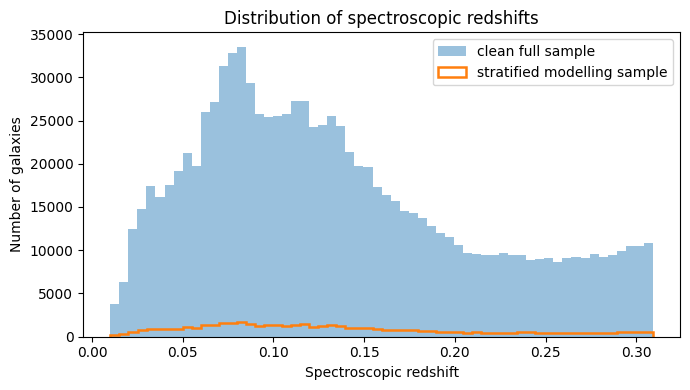

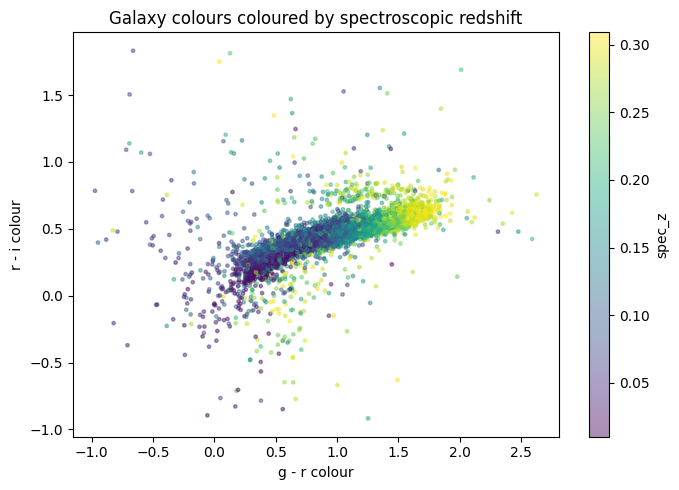

In [6]:
plt.figure(figsize=(7, 4))
plt.hist(clean['spec_z'], bins=60, alpha=0.45, label='clean full sample')
plt.hist(modeling['spec_z'], bins=60, histtype='step', linewidth=1.8, label='stratified modelling sample')
plt.xlabel('Spectroscopic redshift')
plt.ylabel('Number of galaxies')
plt.title('Distribution of spectroscopic redshifts')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'photoz_specz_distribution.png', dpi=160)
plt.show()

plot_sample = modeling.sample(n=min(12000, len(modeling)), random_state=42)
plt.figure(figsize=(7, 5))
plt.scatter(plot_sample['g_r'], plot_sample['r_i'], c=plot_sample['spec_z'], s=6, alpha=0.45)
plt.xlabel('g - r colour')
plt.ylabel('r - i colour')
plt.title('Galaxy colours coloured by spectroscopic redshift')
cb = plt.colorbar()
cb.set_label('spec_z')
plt.tight_layout()
plt.savefig(FIGURES / 'photoz_colour_colour.png', dpi=160)
plt.show()


## Train/test split

All models are evaluated on the same held-out test set. The split is stratified by redshift bins so the test set contains the same broad redshift coverage as the training set.


Training rows: 37500
Testing rows: 12500
Features: ['u', 'g', 'r', 'i', 'zmag', 'u_g', 'g_r', 'r_i', 'i_z', 'r_mag']


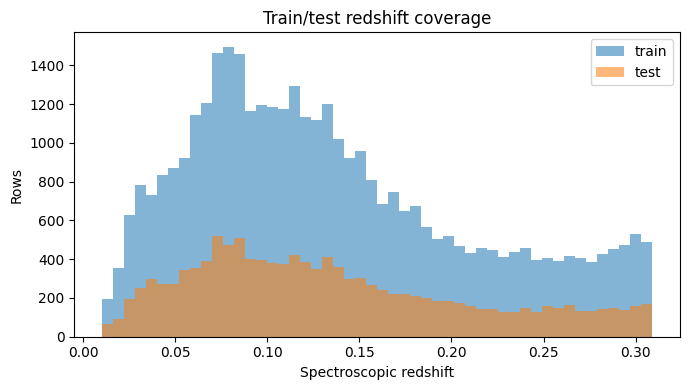

In [7]:
X_train, X_test, y_train, y_test = train_test_photoz(
    modeling,
    PHOTOZ_FEATURES,
    test_size=0.25,
    random_state=42,
    stratify_bins=10,
)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))
print('Features:', PHOTOZ_FEATURES)

plt.figure(figsize=(7, 4))
plt.hist(y_train, bins=50, alpha=0.55, label='train')
plt.hist(y_test, bins=50, alpha=0.55, label='test')
plt.xlabel('Spectroscopic redshift')
plt.ylabel('Rows')
plt.title('Train/test redshift coverage')
plt.legend()
plt.tight_layout()
plt.show()


## Evaluation metrics

For photo-z work, residuals are often normalized by $1+z$:

$$
\Delta z_{norm} = \frac{z_{pred} - z_{spec}}{1 + z_{spec}}.
$$

We report MAE, RMSE, normalized bias, NMAD, catastrophic outlier rate, and R². For the report, **NMAD, bias and outlier rate** are usually more informative than R² alone.


## Fit and compare all models

The following cell trains all models using the same features and same split. The `median_redshift_baseline` is included so the comparison has a true floor: a model is only useful if it beats a constant redshift prediction.


In [8]:
fitted_models, predictions, metrics = fit_and_evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test,
    random_state=42,
)

# If the input file contains an existing catalogue photo-z estimate, evaluate it too.
predictions, metrics = add_catalog_photoz_metrics(modeling, predictions, metrics)

metrics


,model,MAE_z,RMSE_z,bias_mean_dz_norm,NMAD_dz_norm,outlier_rate_abs_dz_norm_gt_0p15,R2
0,random_forest_classical,0.017964,0.026541,0.000641,0.016342,0.00168,0.877492
1,hist_gradient_boosting_classical,0.018317,0.026710,0.000519,0.017027,0.00152,0.875933
2,knn_classical,0.019037,0.027747,0.000835,0.017316,0.00144,0.866105
3,mlp_neural_network,0.018832,0.028274,0.000307,0.017331,0.00200,0.860978
4,decision_tree_classical,0.019954,0.029254,0.000602,0.018140,0.00192,0.851169
5,gradient_boosting_classical,0.019733,0.028289,0.000839,0.018610,0.00160,0.860827
6,ridge_linear_baseline,0.026804,0.036914,0.001625,0.027724,0.00248,0.763022
7,median_redshift_baseline,0.061442,0.077357,-0.009197,0.067556,0.00000,-0.040693


## Metric comparison plots

A table is useful, but plots make the model comparison easier to explain. Expected interpretation:

- the median baseline should be worst;
- ridge regression tests how much a nearly linear colour-redshift relation explains;
- kNN can work well in densely sampled colour space;
- one decision tree often has larger scatter;
- tree ensembles usually improve stability;
- MLP performance depends on scaling, sample size and training stability.


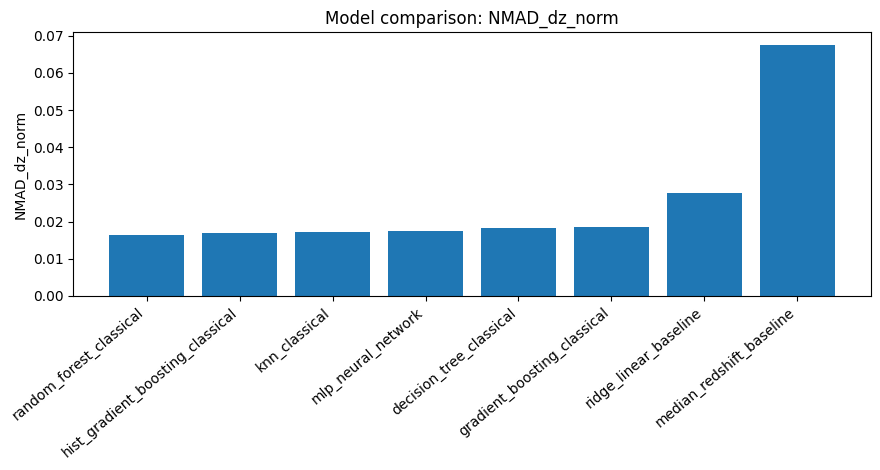

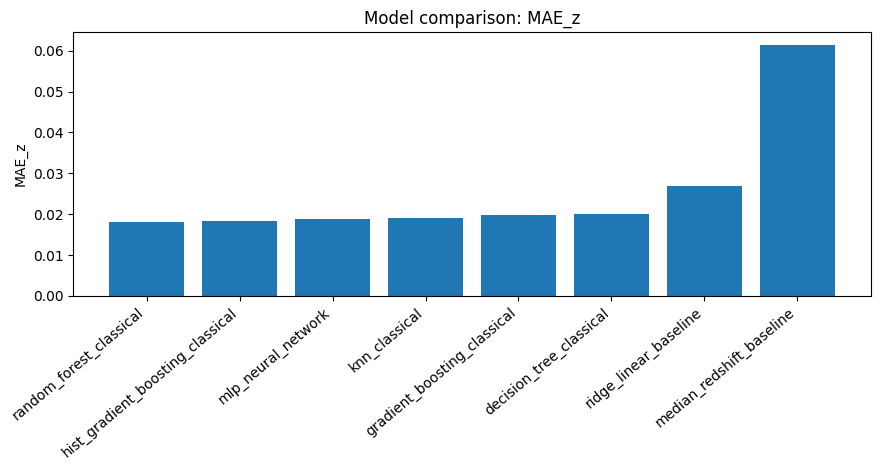

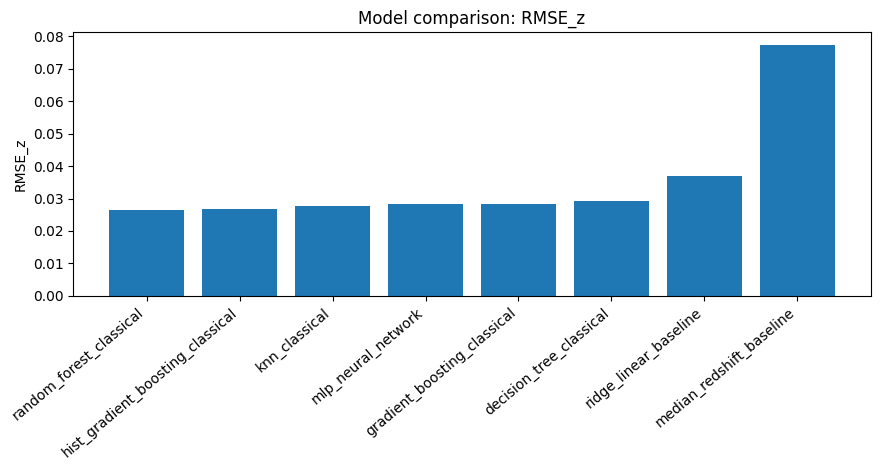

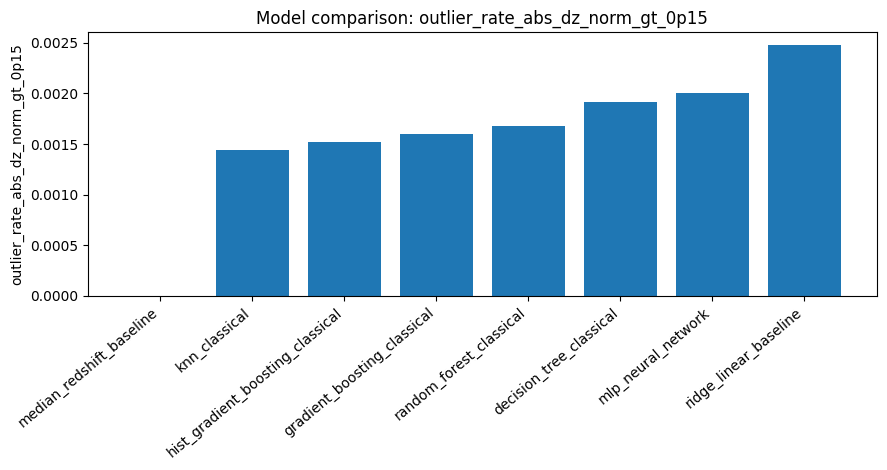

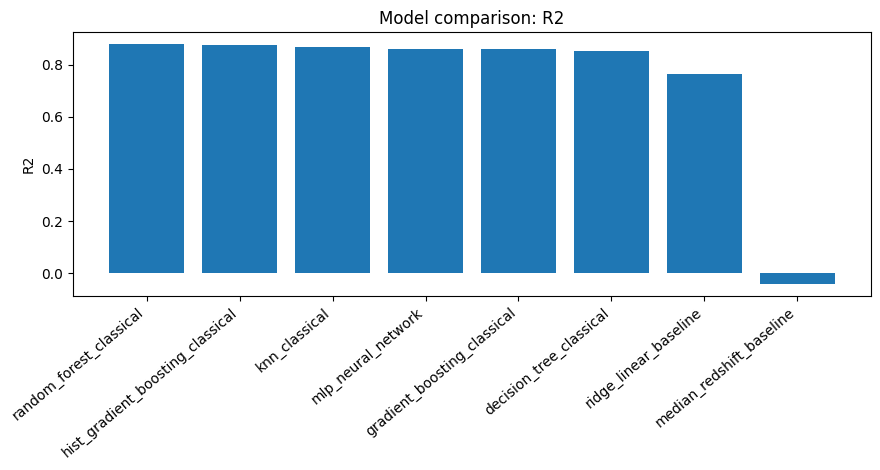

In [9]:
plot_model_metric_comparison(metrics, FIGURES)

for metric in ['NMAD_dz_norm', 'MAE_z', 'RMSE_z', 'outlier_rate_abs_dz_norm_gt_0p15', 'R2']:
    if metric in metrics.columns:
        ordered = metrics.sort_values(metric, ascending=(metric != 'R2'))
        plt.figure(figsize=(9, 4.8))
        plt.bar(ordered['model'], ordered[metric])
        plt.xticks(rotation=40, ha='right')
        plt.ylabel(metric)
        plt.title(f'Model comparison: {metric}')
        plt.tight_layout()
        plt.show()


## Predicted versus true redshift for every model

A good model should lie close to the one-to-one dashed line. Curvature shows systematic bias. Vertical scatter shows uncertainty. Horizontal bands or steps can appear for tree-based models and are a warning sign if they dominate the plot.


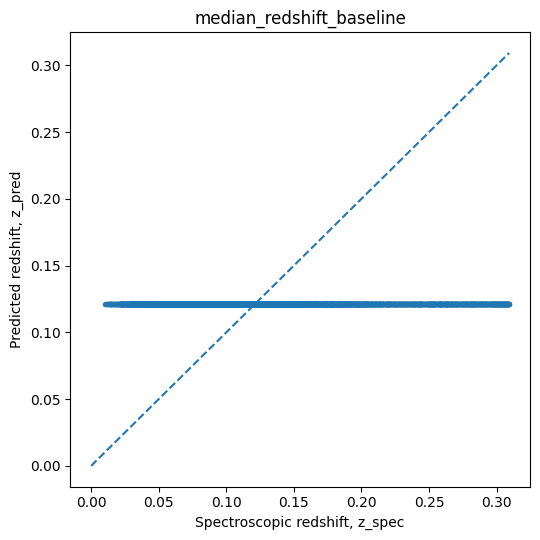

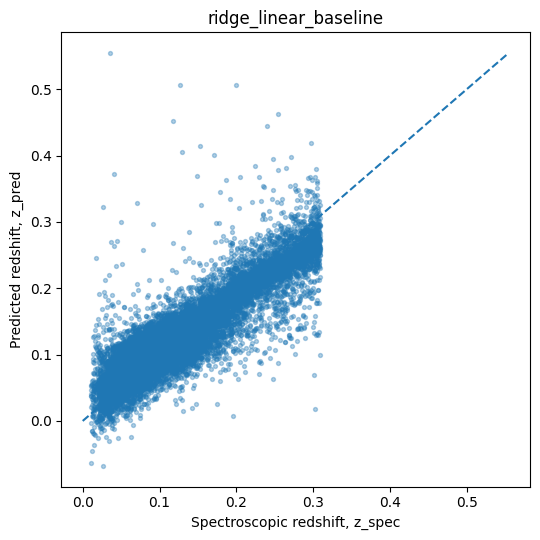

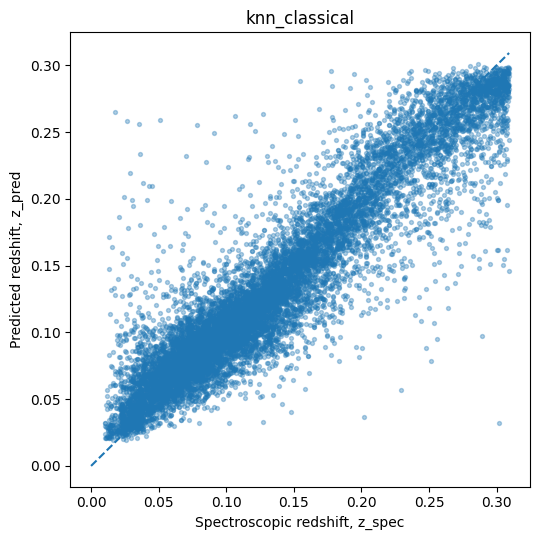

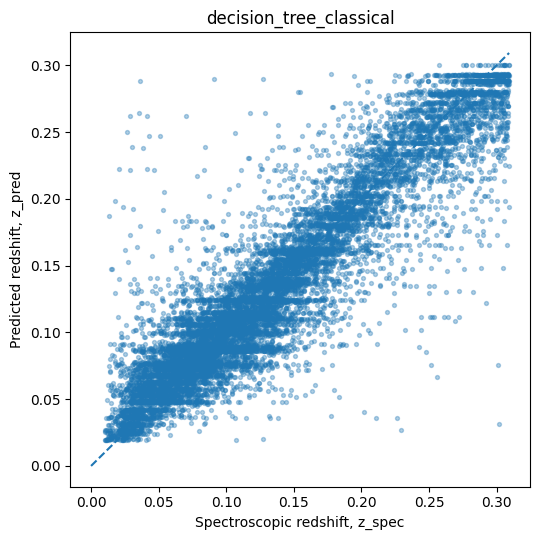

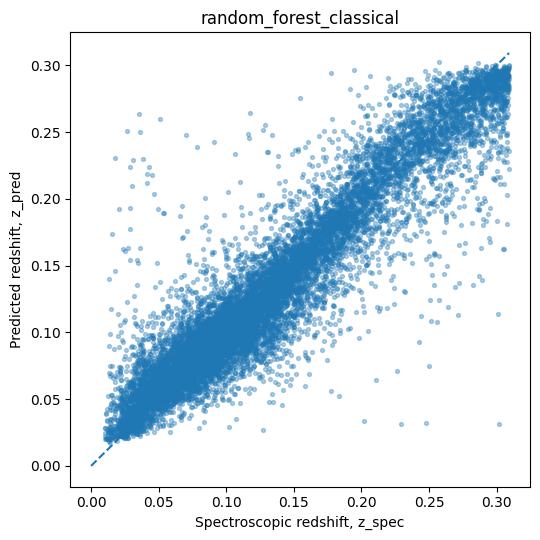

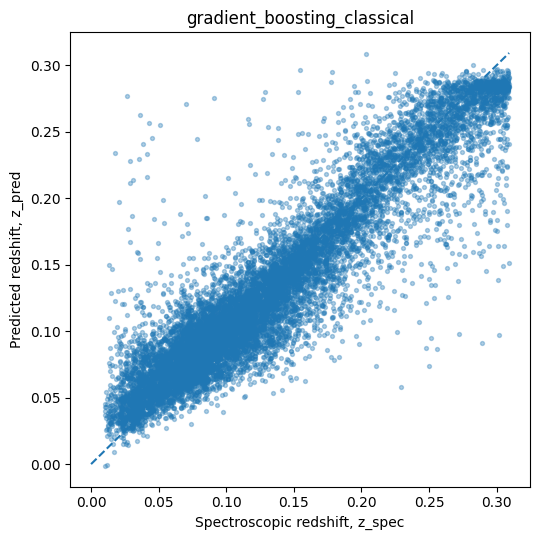

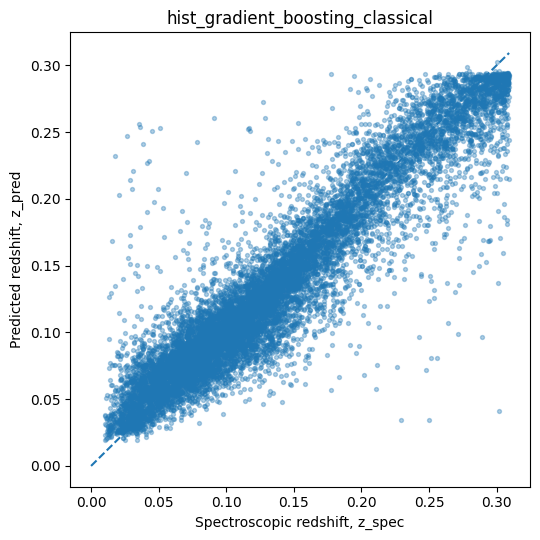

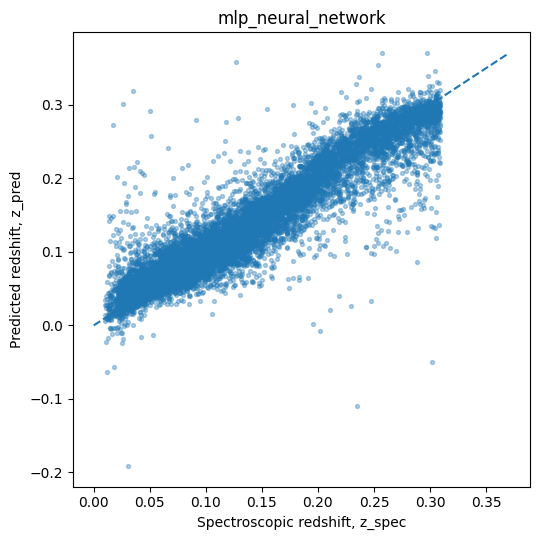

In [10]:
plot_all_predicted_vs_true(predictions, FIGURES)
plot_predictions = predictions[[c for c in predictions.columns if c == 'spec_z' or not c.endswith('_sigma')]]

for model in [c for c in plot_predictions.columns if c != 'spec_z']:
    y_true = plot_predictions['spec_z']
    y_pred = plot_predictions[model]
    lim = [0, max(y_true.max(), y_pred.max())]
    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(y_true, y_pred, s=8, alpha=0.35)
    plt.plot(lim, lim, linestyle='--')
    plt.xlabel('Spectroscopic redshift, z_spec')
    plt.ylabel('Predicted redshift, z_pred')
    plt.title(model)
    plt.tight_layout()
    plt.show()


## Residual comparison

Residual plots are the most important diagnostic. We look for nonzero average residuals, larger scatter at high redshift, catastrophic outliers beyond $|\Delta z_{norm}| > 0.15$, and differences between models that are hidden by a single metric.


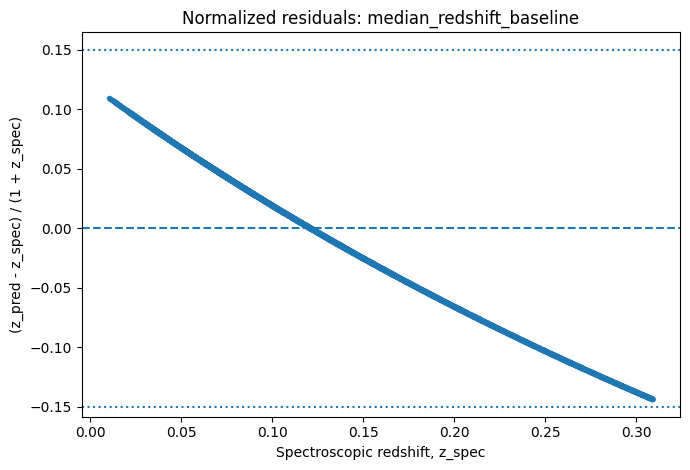

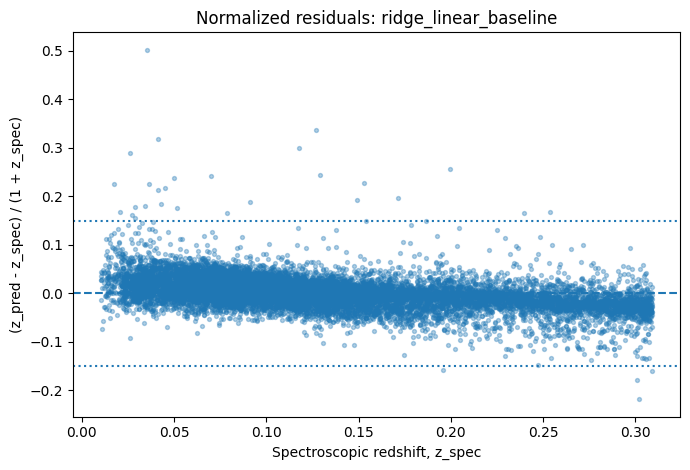

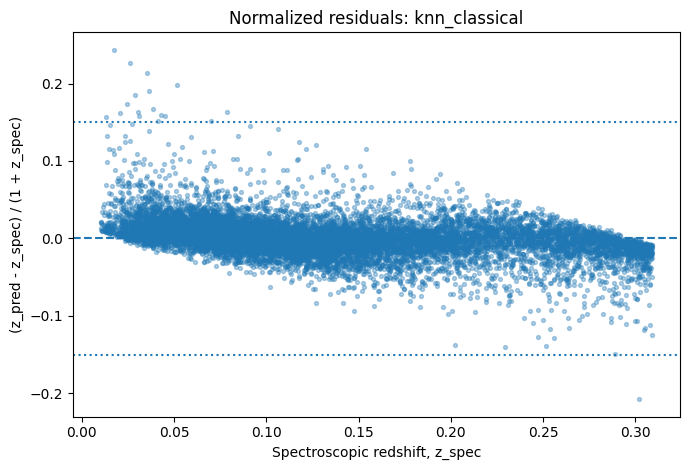

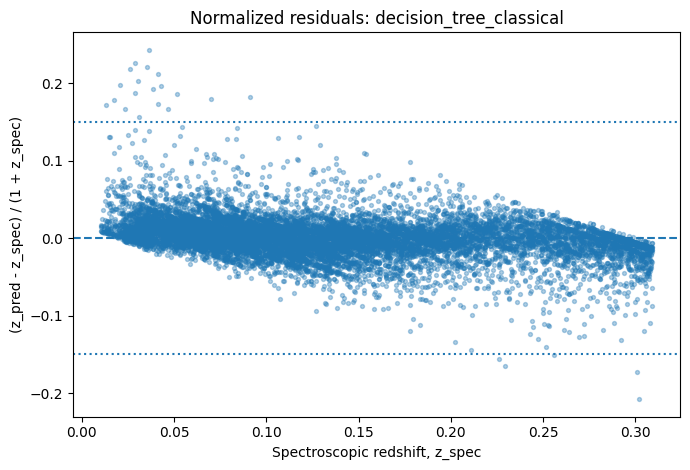

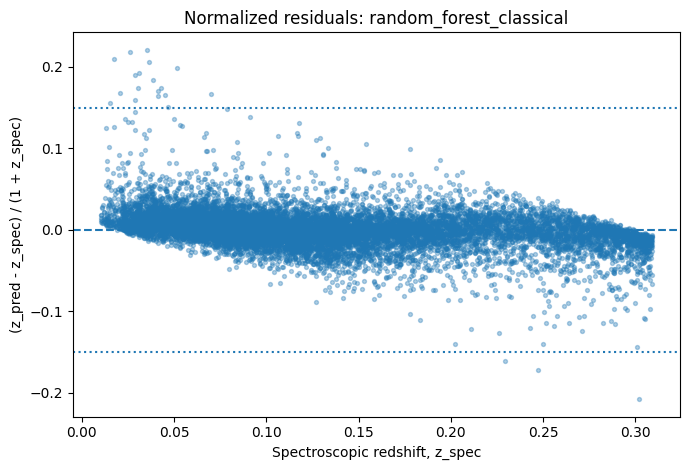

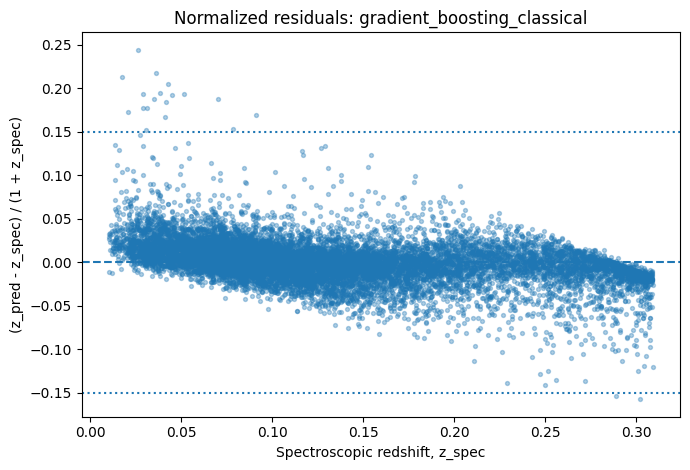

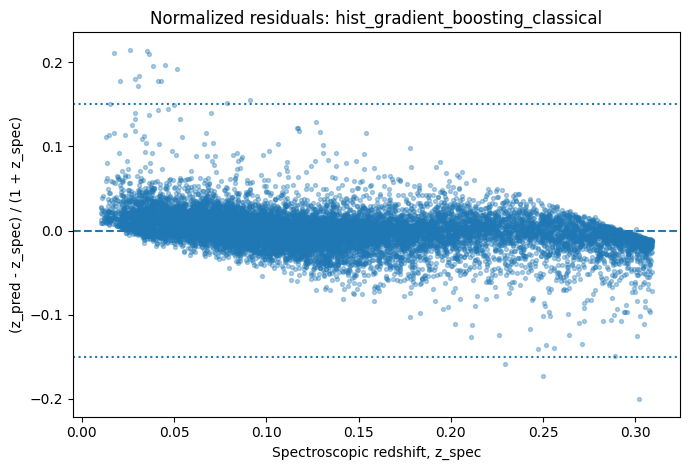

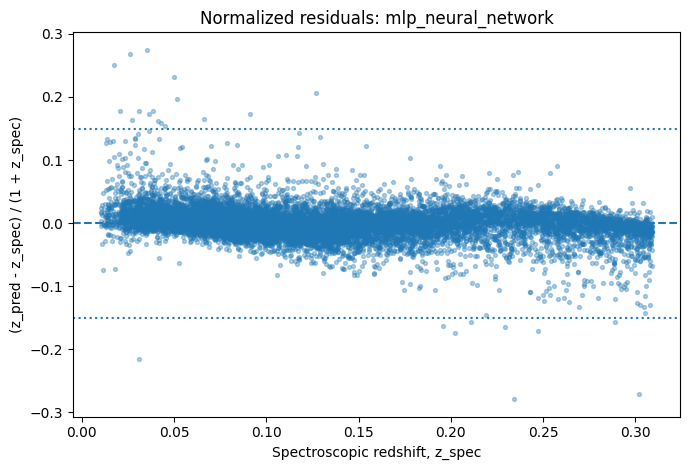

In [11]:
plot_residual_comparisons(predictions, FIGURES)

for model in [c for c in plot_predictions.columns if c != 'spec_z']:
    y_true = plot_predictions['spec_z']
    y_pred = plot_predictions[model]
    dz_norm = (y_pred - y_true) / (1 + y_true)
    plt.figure(figsize=(7, 4.8))
    plt.scatter(y_true, dz_norm, s=8, alpha=0.35)
    plt.axhline(0, linestyle='--')
    plt.axhline(0.15, linestyle=':')
    plt.axhline(-0.15, linestyle=':')
    plt.xlabel('Spectroscopic redshift, z_spec')
    plt.ylabel('(z_pred - z_spec) / (1 + z_spec)')
    plt.title(f'Normalized residuals: {model}')
    plt.tight_layout()
    plt.show()


## Performance as a function of redshift

A model can have good average performance while failing in a specific redshift range. We therefore compute NMAD in redshift bins. This is especially important for photo-z because colour-redshift degeneracies and training-set coverage change with redshift.


In [12]:
binned = binned_residual_summary(plot_predictions)
binned.to_csv(REPORT / 'photoz_binned_residual_summary.csv', index=False)
plot_binned_residual_summary(binned, FIGURES)
binned.head(20)


,model,z_bin,n,median_dz_norm,mean_abs_dz_norm,nmad_dz_norm
0,decision_tree_classical,"(-0.001, 0.1]",4849,0.007380,0.017025,0.016594
1,decision_tree_classical,"(0.1, 0.2]",4960,-0.002829,0.016998,0.017961
2,decision_tree_classical,"(0.2, 0.3]",2438,-0.003766,0.018918,0.019831
3,decision_tree_classical,"(0.3, 0.4]",253,-0.016492,0.023882,0.011459
4,gradient_boosting_classical,"(-0.001, 0.1]",4849,0.009941,0.017798,0.017167
5,gradient_boosting_classical,"(0.1, 0.2]",4960,-0.003867,0.016005,0.016980
6,gradient_boosting_classical,"(0.2, 0.3]",2438,-0.005683,0.018315,0.017965
7,gradient_boosting_classical,"(0.3, 0.4]",253,-0.018240,0.026142,0.007108
8,hist_gradient_boosting_classical,"(-0.001, 0.1]",4849,0.007964,0.015776,0.015372
9,hist_gradient_boosting_classical,"(0.1, 0.2]",4960,-0.003041,0.015467,0.016345


## Worst-object diagnostic

The table below is not for naming individual galaxies in the report. It is a quick sanity check: if the worst objects have extreme colours or sit near the edge of the redshift range, the failure mode is easier to explain.


In [13]:
best_model = metrics.iloc[0]['model']
if best_model in plot_predictions.columns:
    worst = plot_predictions[['spec_z', best_model]].copy()
    worst['abs_dz_norm'] = ((worst[best_model] - worst['spec_z']) / (1 + worst['spec_z'])).abs()
    worst = worst.join(modeling.loc[worst.index, PHOTOZ_FEATURES])
    worst.sort_values('abs_dz_norm', ascending=False).head(10)
else:
    print('Best model is not a prediction column:', best_model)


## Optional uncertainty-style comparison

The TITAN uncertainty-aware examples motivate another useful question: not only **what is the prediction?**, but also **how uncertain is it?**

To keep this project lightweight, we use two simple uncertainty proxies: random-forest tree scatter and MLP ensemble scatter. These are not full Bayesian uncertainties, but they are useful diagnostics. A meaningful uncertainty estimate should correlate positively with absolute prediction error.


In [14]:
uncertainty_rows = []

if 'random_forest_classical' in fitted_models:
    sigma_rf = random_forest_tree_uncertainty(fitted_models['random_forest_classical'], X_test)
    predictions['random_forest_tree_sigma'] = sigma_rf
    row = {'method': 'random_forest_tree_scatter'}
    row.update(uncertainty_diagnostics(y_test, predictions['random_forest_classical'], sigma_rf))
    uncertainty_rows.append(row)

# MLP ensembles can be slow on very large datasets. The stratified sample keeps this optional check reasonable.
if len(X_train) <= 50000:
    mlp_mean, mlp_sigma = fit_mlp_ensemble_uncertainty(X_train, X_test, y_train, n_members=4)
    predictions['mlp_ensemble_mean'] = mlp_mean
    predictions['mlp_ensemble_sigma'] = mlp_sigma

    ensemble_row = {'model': 'mlp_ensemble_mean'}
    ensemble_row.update(photoz_metrics(y_test, mlp_mean))
    metrics = pd.concat([metrics, pd.DataFrame([ensemble_row])], ignore_index=True)
    metrics = metrics.sort_values('NMAD_dz_norm').reset_index(drop=True)

    row = {'method': 'mlp_ensemble_std'}
    row.update(uncertainty_diagnostics(y_test, mlp_mean, mlp_sigma))
    uncertainty_rows.append(row)

uncertainty_summary = pd.DataFrame(uncertainty_rows)
uncertainty_summary.to_csv(REPORT / 'photoz_uncertainty_summary.csv', index=False)
uncertainty_summary


,method,mean_sigma,median_sigma,corr_abs_error_sigma
0,random_forest_tree_scatter,0.017265,0.015023,0.501690
1,mlp_ensemble_std,0.004909,0.003721,0.329539


## Visualizing uncertainty proxies

If the uncertainty proxy is useful, points with larger estimated uncertainty should tend to have larger absolute errors. A weak correlation does not mean the model is useless; it means the uncertainty proxy is not well calibrated.


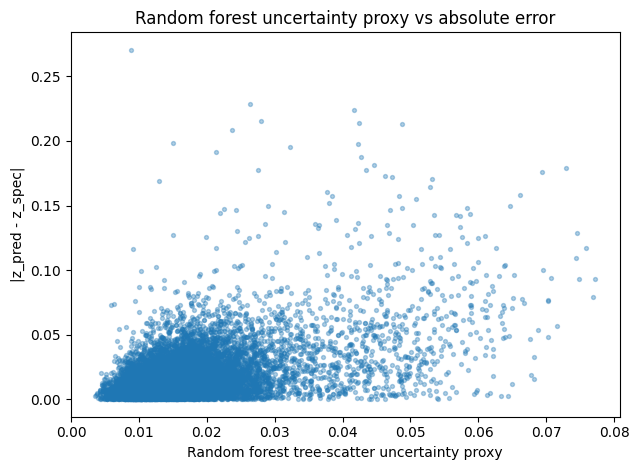

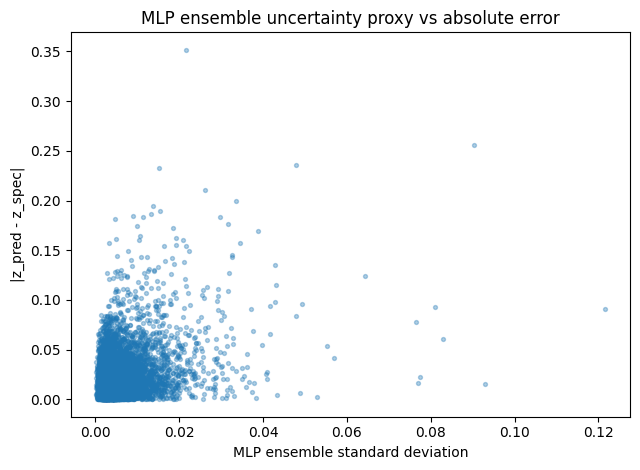

In [15]:
if 'random_forest_tree_sigma' in predictions.columns:
    abs_err = np.abs(predictions['random_forest_classical'] - predictions['spec_z'])
    plt.figure(figsize=(6.5, 4.8))
    plt.scatter(predictions['random_forest_tree_sigma'], abs_err, s=8, alpha=0.35)
    plt.xlabel('Random forest tree-scatter uncertainty proxy')
    plt.ylabel('|z_pred - z_spec|')
    plt.title('Random forest uncertainty proxy vs absolute error')
    plt.tight_layout()
    plt.savefig(FIGURES / 'photoz_rf_uncertainty_vs_error.png', dpi=160)
    plt.show()

if 'mlp_ensemble_sigma' in predictions.columns:
    abs_err = np.abs(predictions['mlp_ensemble_mean'] - predictions['spec_z'])
    plt.figure(figsize=(6.5, 4.8))
    plt.scatter(predictions['mlp_ensemble_sigma'], abs_err, s=8, alpha=0.35)
    plt.xlabel('MLP ensemble standard deviation')
    plt.ylabel('|z_pred - z_spec|')
    plt.title('MLP ensemble uncertainty proxy vs absolute error')
    plt.tight_layout()
    plt.savefig(FIGURES / 'photoz_mlp_uncertainty_vs_error.png', dpi=160)
    plt.show()


## Save outputs

The report can use the following outputs:

- `report/photoz_sample_summary.csv`
- `report/photoz_model_comparison.csv`
- `report/photoz_predictions.csv`
- `report/photoz_residuals_long.csv`
- `report/photoz_binned_residual_summary.csv`
- `report/photoz_uncertainty_summary.csv`
- `figures/photoz_metric_*.png`
- `figures/photoz_*predicted_vs_true*.png`
- `figures/photoz_residual*.png`


In [16]:
final_predictions_for_metrics = predictions[[c for c in predictions.columns if c != 'spec_z' and not c.endswith('_sigma')]]
final_predictions_for_metrics.insert(0, 'spec_z', predictions['spec_z'])
final_binned = binned_residual_summary(final_predictions_for_metrics)

save_predictions_and_metrics(
    predictions,
    metrics,
    REPORT,
    binned_summary=final_binned,
    uncertainty_summary=uncertainty_summary,
)

print('Saved photo-z comparison outputs to:')
print(' ', REPORT)
print(' ', FIGURES)
metrics


Saved photo-z comparison outputs to:
  /home/asura/Downloads/papers/cosmic_expansion_project_photoz_comparison_update/report
  /home/asura/Downloads/papers/cosmic_expansion_project_photoz_comparison_update/figures


,model,MAE_z,RMSE_z,bias_mean_dz_norm,NMAD_dz_norm,outlier_rate_abs_dz_norm_gt_0p15,R2
0,random_forest_classical,0.017964,0.026541,0.000641,0.016342,0.00168,0.877492
1,mlp_ensemble_mean,0.017972,0.026436,0.000228,0.016556,0.00136,0.878459
2,hist_gradient_boosting_classical,0.018317,0.026710,0.000519,0.017027,0.00152,0.875933
3,knn_classical,0.019037,0.027747,0.000835,0.017316,0.00144,0.866105
4,mlp_neural_network,0.018832,0.028274,0.000307,0.017331,0.00200,0.860978
5,decision_tree_classical,0.019954,0.029254,0.000602,0.018140,0.00192,0.851169
6,gradient_boosting_classical,0.019733,0.028289,0.000839,0.018610,0.00160,0.860827
7,ridge_linear_baseline,0.026804,0.036914,0.001625,0.027724,0.00248,0.763022
8,median_redshift_baseline,0.061442,0.077357,-0.009197,0.067556,0.00000,-0.040693


## Conclusion template for the project report

After running the notebook, fill in the model names and values from the metric table:

1. The modelling sample used `...` rows after quality cuts and redshift-stratified sampling.
2. The best-performing model by NMAD was `...`, with NMAD `...` and outlier rate `...`.
3. The best model did/did not clearly beat the median-redshift baseline, showing whether the colours contain useful redshift information.
4. The linear ridge baseline performed `better/worse than expected`, suggesting that the colour-redshift relation is `approximately linear / clearly nonlinear` over this sample.
5. Tree ensembles such as random forest or histogram gradient boosting usually reduce the instability of a single decision tree.
6. Residual plots show whether performance degrades at high redshift or in sparsely sampled colour regions.
7. The uncertainty proxies are useful only if larger predicted uncertainty corresponds to larger absolute error.

Most importantly, photometric redshifts should not be treated as equivalent to spectroscopic redshifts. They are scalable approximations that are valuable for large surveys but have larger scatter and occasional catastrophic outliers.
